# <strong><font color='#3399FF'>1. Acerca del Desafío</font></strong> 
---

## <font color='#0066CC'>Contexto</font>
---

El proyecto propone una situación ficticia donde hemos sido contratados como **analistas de datos** para trabajar específicamente en el 'churn' o cancelaciones de clientes de la empresa Telecom X.

## <font color='#0066CC'>Antecedentes</font>
---

Este proyecto es una continuación del proyecto [challenge-telecom-x](https://github.com/carloslozano-rg/challenge-telecom-x.git), en el cual: 
- Realizamos un tratamiento a los datos.
- Desarrollamos un análisis exploratorio.
- Descubrimos algunos insigths importantes. 
- Proporcionamos algunas recomendaciones de como tratar la raíz del problema.

## <font color='#0066CC'>Objetivo</font>
---

La empresa quiere anticiparse al problema de la cancelación, por lo que la misión que nos han asignado es es **desarrollar modelos predictivos** capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

## <font color='#0066CC'>Conjunto de Datos o Dataset</font>
---

El dataset que vamos a ocupar fue producto del tratamiento de los datos del proyecto [challenge-telecom-x](https://github.com/carloslozano-rg/challenge-telecom-x.git), del DataFrame **telecom_x_estandarizado**, el cual fue convertido a formato csv con el nombre de **'datos_telecom_x.csv'**.

Se realizaron los siguientes tratamientos sobre los datos originales:
- Se eliminaron registros que contenian un carácter vacío en la columna **'cancelacion'**, ya que: 
    - era una columna muy importante para no saber si el cliente había cancelado o no su servicio,
    - y representaban menos del 3% del total.
- Se introdujeron ceros en los registros con un carácter vacío en la columna **'cargo_total'**, ya que representaban a clientes que apenas comenzaban con su servicio.

- Se tradujeron los nombres de varias columnas para mayor claridad.

# <strong><font color='#3399FF'>2. Preparación de los Datos</font></strong> 
---

## <font color='#0066CC'>Extracción de datos tratados</font>
---

### <font color='#003366'>Lectura de Datos</font>
---

Creamos un DataFrame (DF) que contenga la información de los clientes de Telecom X a partir del archivo **'datos_telecom_x.csv'**:

In [142]:
import pandas as pd

In [143]:
telecom_x_df_inicial = pd.read_csv(filepath_or_buffer='datos_telecom_x.csv', sep=',', encoding='UTF-8')
telecom_x_df_inicial.head()

,cliente_id,cancelacion,genero,adulto_mayor,pareja,dependientes,meses_antiguedad,servicio_telefonico,multiples_lineas,servicio_internet,...,proteccion_dispositivos,soporte_tecnologico,streaming_tv,streaming_peliculas,contrato,factura_en_linea,metodo_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,No,DSL,...,No,Si,Si,No,Un año,1,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Si,DSL,...,No,No,No,Si,Por mes,0,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,No,Fibra óptica,...,Si,No,No,No,Por mes,1,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,No,Fibra óptica,...,Si,No,Si,Si,Por mes,1,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,No,Fibra óptica,...,No,Si,Si,No,Por mes,1,Cheque por correo,83.9,267.40,2.80


**Aclaración**: en las columnas 'cancelacion', 'adulto_mayor', 'pareja', 'dependientes', 'servicio_telefonico' y 'factura_en_linea':
- 0 = No
- 1 = Si

Analizamos los metadatos del DF y observamos 22 columnas y 7043 registros:

In [144]:
telecom_x_df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                7043 non-null   object 
 1   cancelacion               7043 non-null   int64  
 2   genero                    7043 non-null   object 
 3   adulto_mayor              7043 non-null   int64  
 4   pareja                    7043 non-null   int64  
 5   dependientes              7043 non-null   int64  
 6   meses_antiguedad          7043 non-null   int64  
 7   servicio_telefonico       7043 non-null   int64  
 8   multiples_lineas          7043 non-null   object 
 9   servicio_internet         7043 non-null   object 
 10  seguridad_en_linea        7043 non-null   object 
 11  copia_seguridad_en_linea  7043 non-null   object 
 12  proteccion_dispositivos   7043 non-null   object 
 13  soporte_tecnologico       7043 non-null   object 
 14  streamin

### <font color='#003366'>Estadística Descriptiva</font>
---

Columnas numéricas:

In [145]:
telecom_x_df_inicial.describe()

,cancelacion,adulto_mayor,pareja,dependientes,meses_antiguedad,servicio_telefonico,factura_en_linea,cargo_mensual,cargo_total,cuentas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


Columnas categóricas:

In [146]:
telecom_x_df_inicial.describe(include='object')

,cliente_id,genero,multiples_lineas,servicio_internet,seguridad_en_linea,copia_seguridad_en_linea,proteccion_dispositivos,soporte_tecnologico,streaming_tv,streaming_peliculas,contrato,metodo_pago
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Masculino,No,Fibra óptica,No,No,No,No,No,No,Por mes,Cheque electrónico
freq,1,3555,3390,3096,3498,3088,3095,3473,2810,2785,3875,2365


# <strong><font color='#3399FF'>3. Correlación y Selección de Variables</font></strong> 
---

## <font color='#0066CC'>Análisis de Correlación</font>
---

El **coeficiente de correlación** es una medida de asociación lineal entre dos variables y su valor está entre -1 y +1, dónde -1 indica asociación negativa perfecta y +1 indica asociación positiva perfecta.

En pocas palabras, mientras más cercana a +1 o -1 sea la correlación entre 2 variables, mejor se puede explicar su relación, por el contrario, si es cercana a 0, quiere decir que el comportamiento de una variable no afecta a la otra.

Para la construcción del modelo es importante verificar si:
- Las variables explicativas (X) tienen una fuerte correlación con la variable dependiente (y).
- Las variables explicativas (X) no tengan una fuerte correlación entre sí.

La variable o columna que nos interesa predecir es **'cancelacion'**, por lo que será nuestra **variable depedendiente (y)**, mientras que todas las demás serán nuestras **variables explicativas (X)**.

Verificamos la correlación entre las variables númericas de todo el conjunto de datos.

In [147]:
# Librerías
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [148]:
def corr_var_num_viz():
    # Argumentos para gráfico
    corr_var_num = telecom_x_df_inicial.corr(numeric_only=True)
    mascara = np.zeros_like(a=corr_var_num, dtype=bool)
    mascara[np.triu_indices_from(mascara)] = True

    # Configuramos el lienzo de matplotlib
    fig, ax = plt.subplots(figsize=(9,7))
    # Generamos mapa de calor
    color_map = sns.diverging_palette(h_neg=220, h_pos=10, as_cmap=True)
    # Creamos el gráfico
    sns.heatmap(
        data=corr_var_num,
        mask=mascara,
        cmap=color_map,
        vmax=1,
        vmin=-1,
        center=0,
        square=True,
        linewidths=1.5,
        annot=True,
        cbar_kws={"shrink": 0.5}
    )
    ax.set_title(label='Mapa de calor para correlaciones de variables numéricas \nen el conjunto de datos de Telecom X', fontsize=18, fontweight='bold', pad=15)
    return plt

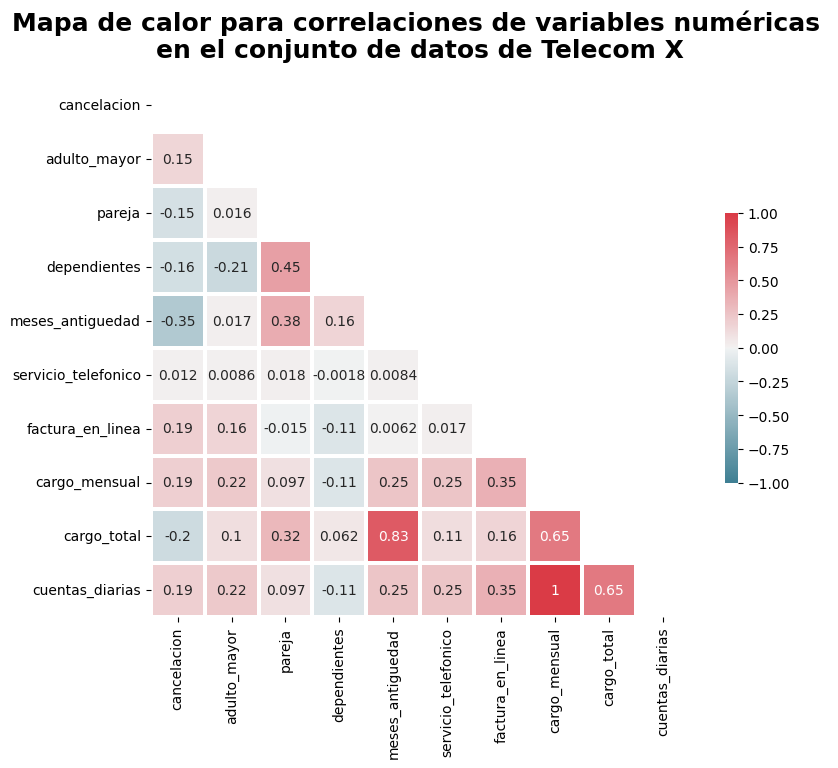

In [149]:
corr_var_num_viz().show();

## <font color='#0066CC'>Eliminación de Columnas Irrelevantes</font>
---

Las columnas que filtraremos son:
- `cliente_id`: sólo es un identificador que no aporta valor real al modelo predictivo.
- `cargo_mensual`: se podría obtener de multiplicar `cuentas_diarias` por 30, es por eso que ambas variables tienen una asociación positiva perfecta.
- `cargo_total`: se podría obtener de multiplicar `cuentas_diarias` por 30 por `meses_antiguedad`, es por eso que dichas variables tienen una asociación positiva muy alta.

In [150]:
columnas_irrelevantes_1 = ['cliente_id', 'cargo_mensual', 'cargo_total']

telecom_x_df_fil_1 = telecom_x_df_inicial.drop(columns=columnas_irrelevantes_1)
telecom_x_df_fil_1.head()

,cancelacion,genero,adulto_mayor,pareja,dependientes,meses_antiguedad,servicio_telefonico,multiples_lineas,servicio_internet,seguridad_en_linea,copia_seguridad_en_linea,proteccion_dispositivos,soporte_tecnologico,streaming_tv,streaming_peliculas,contrato,factura_en_linea,metodo_pago,cuentas_diarias
0,0,Femenino,0,1,1,9,1,No,DSL,No,Si,No,Si,Si,No,Un año,1,Cheque por correo,2.19
1,0,Masculino,0,0,0,9,1,Si,DSL,No,No,No,No,No,Si,Por mes,0,Cheque por correo,2.00
2,1,Masculino,0,0,0,4,1,No,Fibra óptica,No,No,Si,No,No,No,Por mes,1,Cheque electrónico,2.46
3,1,Masculino,1,1,0,13,1,No,Fibra óptica,No,Si,Si,No,Si,Si,Por mes,1,Cheque electrónico,3.27
4,1,Femenino,1,1,0,3,1,No,Fibra óptica,No,No,No,Si,Si,No,Por mes,1,Cheque por correo,2.80


## <font color='#0066CC'>Análisis Dirigido</font>
---

Tomando como referencia tanto el análisis de datos llevado en la parte 1 de este proyecto [challenge-telecom-x](https://github.com/carloslozano-rg/challenge-telecom-x.git), así como en el mapa de correlaciones, podemos ver que algunas de las variables que tienen más influencia en la cancelación son:
- `meses_antiguedad`
- `cuentas_diarias`
- `metodo_pago`

De igual forma es útil definir una paleta de colores para los gráficos:

In [151]:
# Paleta de colores
ROJO_1, ROJO_2, ROJO_3 = "#e23155", "#cc2c4e", "#b32742"

AZUL_1, AZUL_2, AZUL_3 = "#203f75", "#1c3867", "#19325b"

BLANCO, GRIS_1, GRIS_2, GRIS_3, GRIS_4, GRIS_5 = \
"#ffffff", "#ebebeb", "#d9d9d9", "#cccccc", "#555655", "#231f20"

AGUA_1, AGUA_2, AGUA_3 = "#addcd4", "#9fccc5", "#96bfb9"

### <font color='#003366'>'cancelacion' X 'meses_antiguedad'</font>
---

In [152]:
def meses_antiguedad_viz():

    fig, axes = plt.subplots(1, 2, figsize=(10, 3), facecolor=GRIS_1, sharey=True)
    axes = axes.flatten()

    # Gráfico 1
    ax_0 = axes[0]
    datos_cancelados = telecom_x_df_fil_1.query('cancelacion == 1')['meses_antiguedad']
    bins_por_semestre = datos_cancelados.max()//6
    counts, bins, patches = ax_0.hist(x=datos_cancelados, bins=bins_por_semestre, color=ROJO_2)

    ax_0.xaxis.set_major_locator(plt.MultipleLocator(6))
    ax_0.yaxis.set_major_locator(plt.MultipleLocator(250))
    ax_0.set_title(label='Histograma de cancelaciones', fontsize=11, fontweight='bold', pad=10)  
    ax_0.margins(y=0.1)
    ax_0.grid(axis='y', alpha=0.4, linestyle='--', color=GRIS_5)

    # Insight 1
    total_clientes_cancelados = datos_cancelados.count()
    counts_max = counts.max()
    porcentaje = (counts_max*100/total_clientes_cancelados).round(2)

    insight = f'$\\bf{porcentaje}$% del total de clientes que dejaron Telecom X \nlo hicieron en los primeros 6 meses.'
    ax_0.text(x=18, y=780, s=insight, fontsize=8)

    # Gráfico 2
    ax_1 = axes[1]
    datos_clientes_actuales = telecom_x_df_fil_1.query('cancelacion == 0')['meses_antiguedad']
    ax_1.hist(x=datos_clientes_actuales, bins=bins_por_semestre, color=AZUL_2)

    ax_1.xaxis.set_major_locator(plt.MultipleLocator(6))
    ax_1.set_title(label='Histograma de clientes actuales', fontsize=11, fontweight='bold', pad=10)  
    ax_1.margins(y=0.1)
    ax_1.grid(axis='y', alpha=0.4, linestyle='--', color=GRIS_5)

    # Título general 
    fig.suptitle('Comparativa entre clientes que han cancelado y clientes actuales \nde Telecom X por meses(semestres) de antigüedad', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return plt

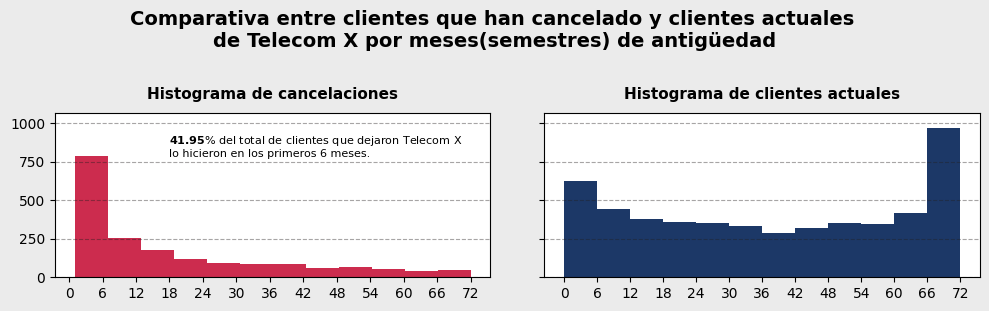

In [153]:
meses_antiguedad_viz().show();

Podemos notar que uno de los principales retos de Telecom X es conservar a un cliente nuevo en los 6 primeros meses de contratación. Después de ese lapso de tiempo el riesgo de cancelación disminuye considerablemente. 

### <font color='#003366'>'cancelacion' X 'cuentas_diarias'</font>
---

In [154]:
def cuentas_diarias_viz():

    fig, axes = plt.subplots(1, 2, figsize=(10, 3), facecolor=GRIS_1, sharey=True)
    axes = axes.flatten()

    # Gráfico 1
    ax_0 = axes[0]
    datos_cancelados = telecom_x_df_fil_1.query('cancelacion == 1')['cuentas_diarias']
    bins_por_unidad = round(datos_cancelados.max()/1)
    counts, bins, patches = ax_0.hist(x=datos_cancelados, bins=bins_por_unidad, color=ROJO_2)

    ax_0.set_xticks(ticks=bins)    
    ax_0.yaxis.set_major_locator(plt.MultipleLocator(250))
    ax_0.set_title(label='Histograma de cancelaciones', fontsize=11, fontweight='bold', pad=10)  
    ax_0.margins(y=0.1)
    ax_0.grid(axis='y', alpha=0.4, linestyle='--', color=GRIS_5)

    # Insight 1
    total_clientes_cancelados = datos_cancelados.count()
    counts_max = counts.max()
    porcentaje = (counts_max*100/total_clientes_cancelados).round(2)

    insight = f'$\\bf{porcentaje}$% del total de clientes que \ndejaron Telecom X gastaron \nun estimado de entre $2-3 diarios.'
    ax_0.text(x=0.6, y=1000, s=insight, fontsize=8)

    # Gráfico 2
    ax_1 = axes[1]
    datos_clientes_actuales = telecom_x_df_fil_1.query('cancelacion == 0')['cuentas_diarias']
    ax_1.hist(x=datos_clientes_actuales, bins=bins_por_unidad, color=AZUL_2)

    ax_1.set_xticks(ticks=bins)
    ax_1.set_title(label='Histograma de clientes actuales', fontsize=11, fontweight='bold', pad=10)  
    ax_1.margins(y=0.1)
    ax_1.grid(axis='y', alpha=0.4, linestyle='--', color=GRIS_5)

    # Título general y etiquetas generales
    fig.suptitle('Comparativa entre clientes que han cancelado y clientes actuales \nde Telecom X por cantidad estimada diaria gastada', fontsize=14, fontweight='bold', y=1.02)
    fig.supxlabel(t='Estimado de dinero diario gastado ($)', fontsize=9)
    fig.supylabel(t='Cantidad de clientes', fontsize=9)
    plt.tight_layout()
    return plt

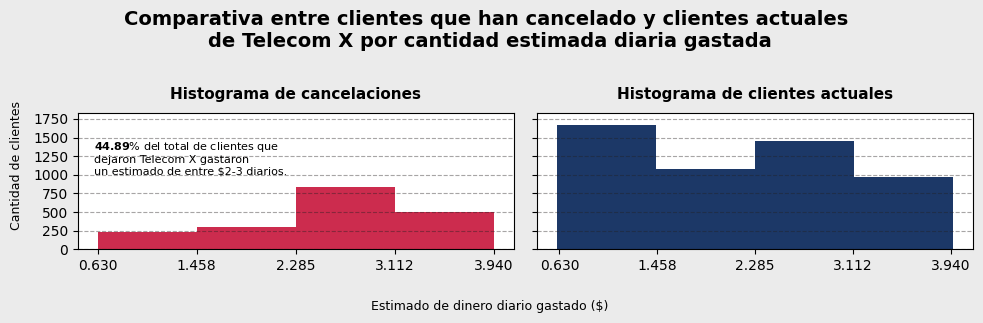

In [155]:
cuentas_diarias_viz().show();

Podemos comprobar que casi la mitad de los clientes de abandonaron Telecom X, gastaban un estimado diario de entre $2 y $3. 

### <font color='#003366'>'cancelacion' X 'metodo_pago'</font>
---

In [156]:
def metodo_pago_viz():
    fig, ax = plt.subplots(figsize=(5,3), facecolor=GRIS_1)
    # Fondo de ceros para apilar barras
    fondo_barras_0 = np.zeros(len(telecom_x_df_fil_1['metodo_pago'].unique()))
    bar_color = [AGUA_1, ROJO_2]

    # Gráfico
    for unique_value in telecom_x_df_fil_1['cancelacion'].unique():
        categorias = telecom_x_df_fil_1.query(f'cancelacion == {unique_value}')['metodo_pago'].value_counts().sort_index().index
        altura_barra = np.array(telecom_x_df_fil_1.query(f'cancelacion == {unique_value}')['metodo_pago'].value_counts().sort_index())
        ax.bar(x=categorias, height=altura_barra, bottom=fondo_barras_0, color=bar_color[unique_value])
        # Etiquetas de texto
        for i, v in enumerate(altura_barra):
            font_weight = 'bold' if unique_value == 1 and v == altura_barra.max() else 'normal'
            ax.text(x=i, y=fondo_barras_0[i] + v/2 - 75, s=str(v), color='black', fontsize=9, ha='center', va='bottom', fontweight=font_weight)
        fondo_barras_0 += altura_barra

    # Insight
    total_clientes = telecom_x_df_fil_1['cancelacion'].count()
    max_cancelados_categoria = telecom_x_df_fil_1.query('cancelacion == 1')['metodo_pago'].value_counts().max()
    porcentaje = (max_cancelados_categoria*100/total_clientes).round(2)

    insight = f'Del total de clientes, $\\bf{porcentaje}$% usaban \nCheques electrónicos al momento de cancelar.'
    ax.text(x=0.6, y=1950, s=insight, fontsize=8)

    # Leyenda
    ax.legend(labels=['No cancelaron', 'Cancelaron'], fontsize=8, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2)

    # Título general y ajuestes generales
    ax.get_xticklabels()[0].set_fontweight('bold')
    ax.set_title(label='Distribución de cancelaciones de \nTelecom X por método de pago', fontdict={'fontsize':12, 'fontweight': 'bold', 'color': GRIS_5}, loc='center', pad=25)
    ax.set_frame_on(False)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_tick_params(which='both', length=0, labelsize=8, labelrotation=45)

    return plt

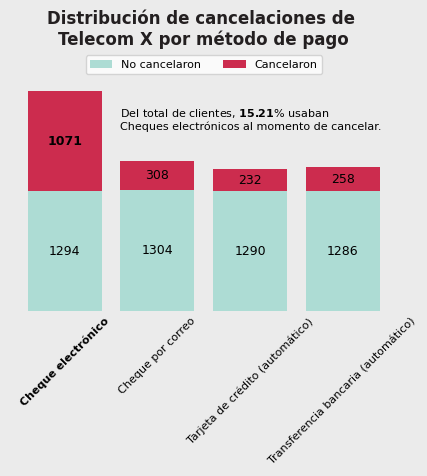

In [157]:
metodo_pago_viz().show();

En comparación con los demás métodos de pago, el Cheque electrónico tiene casi una relación de 50/50 de clientes que cancelaron y clientes que permanecieron.

In [158]:
def contrato_viz():
    fig, ax = plt.subplots(figsize=(5,3), facecolor=GRIS_1)
    # Fondo de ceros para apilar barras
    fondo_barras_0 = np.zeros(len(telecom_x_df_fil_1['contrato'].unique()))
    bar_color = [AGUA_1, ROJO_2]

    # Gráfico
    for unique_value in telecom_x_df_fil_1['cancelacion'].unique():
        categorias = telecom_x_df_fil_1.query(f'cancelacion == {unique_value}')['contrato'].value_counts().sort_index().index
        altura_barra = np.array(telecom_x_df_fil_1.query(f'cancelacion == {unique_value}')['contrato'].value_counts().sort_index())
        ax.bar(x=categorias, height=altura_barra, bottom=fondo_barras_0, color=bar_color[unique_value])
        # Etiquetas de texto
        for i, v in enumerate(altura_barra):
            font_weight = 'bold' if unique_value == 1 and v == altura_barra.max() else 'normal'
            ax.text(x=i, y=fondo_barras_0[i] + v/2 - 75, s=str(v), color='black', fontsize=9, ha='center', va='bottom', fontweight=font_weight)
        fondo_barras_0 += altura_barra

    # Insight
    total_clientes = telecom_x_df_fil_1['cancelacion'].count()
    max_cancelados_categoria = telecom_x_df_fil_1.query('cancelacion == 1')['contrato'].value_counts().max()
    porcentaje = (max_cancelados_categoria*100/total_clientes).round(2)

    insight = f'Del total de clientes, \n$\\bf{porcentaje}$% preferían \nContrato por Mes \nal momento de \ncancelar.'
    ax.text(x=1.6, y=2800, s=insight, fontsize=8)

    # Leyenda
    ax.legend(labels=['No cancelaron', 'Cancelaron'], fontsize=8, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2)

    # Título general y ajuestes generales
    ax.get_xticklabels()[1].set_fontweight('bold')
    ax.set_title(label='Distribución de cancelaciones de \nTelecom X por contrato', fontdict={'fontsize':12, 'fontweight': 'bold', 'color': GRIS_5}, loc='center', pad=25)
    ax.set_frame_on(False)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_tick_params(which='both', length=0, labelsize=8, labelrotation=45)

    return plt

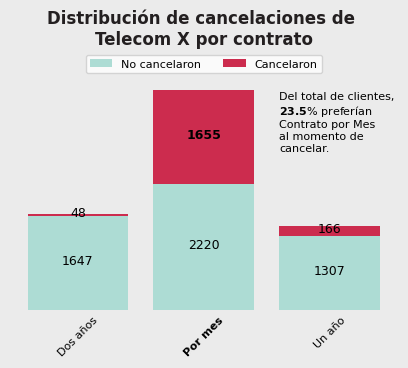

In [159]:
contrato_viz().show()

Del total de clientes que tienen Contrato por Mes, casí la mitad (42%) termino cancelando su servicio.

# <strong><font color='#3399FF'>4. Encoding</font></strong> 
---

## <font color='#0066CC'>Variable Dependiente y Variables Explicativas</font>
---

La variable o columna que nos interesa predecir es **'cancelacion'**, por lo que será nuestra **variable depedendiente (y)**, mientras que todas las demás serán nuestras **variables explicativas (X)**.

In [160]:
y_ini = telecom_x_df_fil_1['cancelacion'].copy()
y_ini.head()

0    0
1    0
2    1
3    1
4    1
Name: cancelacion, dtype: int64

In [161]:
X_ini = telecom_x_df_fil_1.drop(columns='cancelacion') 
X_ini.head()

,genero,adulto_mayor,pareja,dependientes,meses_antiguedad,servicio_telefonico,multiples_lineas,servicio_internet,seguridad_en_linea,copia_seguridad_en_linea,proteccion_dispositivos,soporte_tecnologico,streaming_tv,streaming_peliculas,contrato,factura_en_linea,metodo_pago,cuentas_diarias
0,Femenino,0,1,1,9,1,No,DSL,No,Si,No,Si,Si,No,Un año,1,Cheque por correo,2.19
1,Masculino,0,0,0,9,1,Si,DSL,No,No,No,No,No,Si,Por mes,0,Cheque por correo,2.00
2,Masculino,0,0,0,4,1,No,Fibra óptica,No,No,Si,No,No,No,Por mes,1,Cheque electrónico,2.46
3,Masculino,1,1,0,13,1,No,Fibra óptica,No,Si,Si,No,Si,Si,Por mes,1,Cheque electrónico,3.27
4,Femenino,1,1,0,3,1,No,Fibra óptica,No,No,No,Si,Si,No,Por mes,1,Cheque por correo,2.80


## <font color='#0066CC'>One Hot Encoding</font>
---

Los algoritmos de aprendizaje automático no comprenden datos en formato de texto, por lo que debemos transformar los datos a un formato numérico para que el algoritmo pueda interpretar la información.

Hay varias formas ideales de hacer este tipo de transformación, que mantiene la información original, puede ser con la función de Pandas `get_dummies()` o con `OneHotEncoder()` de Scikit-lean.

Esta acción transforma cada una de las clases de las **variables categóricas** en nuevas columnas, utilizando el valor 0 para representar la ausencia de la característica y 1 para la presencia de la característica en la muestra de la base de datos

La variable dependiente `cancelacion` ya tiene el formato adecuado, no necesita codificarse.

Por otro lado, las variables o columnas categóricas del conjunto de variables explicativas si necesitan ser codificadas.

In [162]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

Identificamos las variables categóricas:

In [163]:
columnas_categoricas = [col_categorica for col_categorica in X_ini.columns if X_ini[col_categorica].dtype == 'object']
columnas_categoricas

['genero',
 'multiples_lineas',
 'servicio_internet',
 'seguridad_en_linea',
 'copia_seguridad_en_linea',
 'proteccion_dispositivos',
 'soporte_tecnologico',
 'streaming_tv',
 'streaming_peliculas',
 'contrato',
 'metodo_pago']

Construimos el codificador y lo usamos sobre las variables categóricas:

In [164]:
encoder = make_column_transformer(
    (OneHotEncoder(drop='if_binary', handle_unknown='ignore'), columnas_categoricas),
    remainder='passthrough',
    sparse_threshold=0,
    verbose_feature_names_out=False
)

Notar que arroja un array y no un DF:

In [165]:
X_encoded_arr = encoder.fit_transform(X_ini)
X_encoded_arr

array([[0.  , 1.  , 0.  , ..., 1.  , 1.  , 2.19],
       [1.  , 0.  , 1.  , ..., 1.  , 0.  , 2.  ],
       [1.  , 1.  , 0.  , ..., 1.  , 1.  , 2.46],
       ...,
       [1.  , 1.  , 0.  , ..., 1.  , 1.  , 1.68],
       [1.  , 1.  , 0.  , ..., 1.  , 0.  , 2.26],
       [1.  , 0.  , 0.  , ..., 0.  , 0.  , 1.97]])

La nueva nomenclatura que vamos a manejar para las nombres de las columnas categóricas transformadas será: 
- `columna_original_1__Categoría_uno`
- `columna_original_1__Categoría_dos`

Es decir, el nombre de la columna original en minúscula, seguido de doble guión bajo, y el nombre de la categoría empezando por mayúscula.


In [166]:
import re

In [167]:
nuevas_columnas_categoricas = [re.sub(pattern=r'_(?=[A-Z])', repl='__', string=columna.replace(' ', '_'), count=1) for columna in encoder.get_feature_names_out(X_ini.columns)]
nuevas_columnas_categoricas

['genero__Masculino',
 'multiples_lineas__No',
 'multiples_lineas__Si',
 'multiples_lineas__Sin_servicio_de_teléfono',
 'servicio_internet__DSL',
 'servicio_internet__Fibra_óptica',
 'servicio_internet__No',
 'seguridad_en_linea__No',
 'seguridad_en_linea__Si',
 'seguridad_en_linea__Sin_servicio_de_internet',
 'copia_seguridad_en_linea__No',
 'copia_seguridad_en_linea__Si',
 'copia_seguridad_en_linea__Sin_servicio_de_internet',
 'proteccion_dispositivos__No',
 'proteccion_dispositivos__Si',
 'proteccion_dispositivos__Sin_servicio_de_internet',
 'soporte_tecnologico__No',
 'soporte_tecnologico__Si',
 'soporte_tecnologico__Sin_servicio_de_internet',
 'streaming_tv__No',
 'streaming_tv__Si',
 'streaming_tv__Sin_servicio_de_internet',
 'streaming_peliculas__No',
 'streaming_peliculas__Si',
 'streaming_peliculas__Sin_servicio_de_internet',
 'contrato__Dos_años',
 'contrato__Por_mes',
 'contrato__Un_año',
 'metodo_pago__Cheque_electrónico',
 'metodo_pago__Cheque_por_correo',
 'metodo_pago__T

Construimos el nuevo DF de variables explicativas ya codificado:

In [168]:
with pd.option_context('display.max_columns', None):
    X_encoded = pd.DataFrame(data=X_encoded_arr, columns=nuevas_columnas_categoricas)
    display(X_encoded.head())

,genero__Masculino,multiples_lineas__No,multiples_lineas__Si,multiples_lineas__Sin_servicio_de_teléfono,servicio_internet__DSL,servicio_internet__Fibra_óptica,servicio_internet__No,seguridad_en_linea__No,seguridad_en_linea__Si,seguridad_en_linea__Sin_servicio_de_internet,copia_seguridad_en_linea__No,copia_seguridad_en_linea__Si,copia_seguridad_en_linea__Sin_servicio_de_internet,proteccion_dispositivos__No,proteccion_dispositivos__Si,proteccion_dispositivos__Sin_servicio_de_internet,soporte_tecnologico__No,soporte_tecnologico__Si,soporte_tecnologico__Sin_servicio_de_internet,streaming_tv__No,streaming_tv__Si,streaming_tv__Sin_servicio_de_internet,streaming_peliculas__No,streaming_peliculas__Si,streaming_peliculas__Sin_servicio_de_internet,contrato__Dos_años,contrato__Por_mes,contrato__Un_año,metodo_pago__Cheque_electrónico,metodo_pago__Cheque_por_correo,metodo_pago__Tarjeta_de_crédito_(automático),metodo_pago__Transferencia_bancaria_(automático),adulto_mayor,pareja,dependientes,meses_antiguedad,servicio_telefonico,factura_en_linea,cuentas_diarias
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,9.0,1.0,1.0,2.19
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9.0,1.0,0.0,2.00
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,2.46
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,13.0,1.0,1.0,3.27
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,1.0,1.0,2.80


Hay que notar que ¡pasamos de 18 columnas a tener 39!.

In [169]:
X_ini.shape

(7043, 18)

In [170]:
X_encoded.shape

(7043, 39)

# <strong><font color='#3399FF'>5. Modelado Predictivo</font></strong> 
---

Antes de crear un modelo predictivo, hay varios temas que debemos tener en consideración.

## <font color='#0066CC'>Normalización</font>
---

La normalización sitúa los datos en el rango entre 0 y 1 o -1 y 1 (si hay valores negativos), sin distorsionar las diferencias en los rangos de valores. Es decir, no elimina valores atípicos (valores extremos).

En algunos modelos es importante transformar las variables explicativas para que se encuentren en la misma escala de magnitud, a esto se le conoce como normalizar.
De esta forma evitamos que una variable tenga más peso que otra.

Por ejemplo, en el caso de `meses_antiguedad` contra `cuentas_diarias` tienen una escala de magnitud diferente que se ve reflejada en sus medidas estadísticas:

In [171]:
telecom_x_df_fil_1[['meses_antiguedad', 'cuentas_diarias']].describe()

,meses_antiguedad,cuentas_diarias
count,7043.000000,7043.000000
mean,32.371149,2.158675
std,24.559481,1.003088
min,0.000000,0.610000
25%,9.000000,1.180000
50%,29.000000,2.340000
75%,55.000000,2.990000
max,72.000000,3.960000


In [172]:
from sklearn.preprocessing import MinMaxScaler

In [173]:
norm_opciones = {
    'sin_norm': None, # Sin nromalización.
    'minmax': MinMaxScaler() # Con normalización.
}

## <font color='#0066CC'>Verificación de la Proporción de Cancelación</font>
---

Evaluamos si existe un desbalance entre las clases de `cancelación`, es decir, entre los clientes que cancelaron y aquellos que continuaron con el servicio de Telecom X, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

In [174]:
def proporcion_cancelacion_viz():
    plt.subplots(figsize=(5,3), facecolor=GRIS_1)

    patches, texts, autotexts = plt.pie(x=y_ini.value_counts(), explode=[0,0.1], labels=['No', 'Si'], colors=[AGUA_2, ROJO_3], autopct='%1.1f%%', pctdistance=0.5, labeldistance=1.1, startangle=90, textprops={'fontsize': 10})

    plt.title(label='Porcentaje de Clientes \nque han cancelado Telecom X', fontdict={'fontsize':12, 'fontweight': 'bold', 'color': GRIS_5}, loc= 'center')

    autotexts[1].set_weight('bold')
    texts[1].set_weight('bold')

    return plt

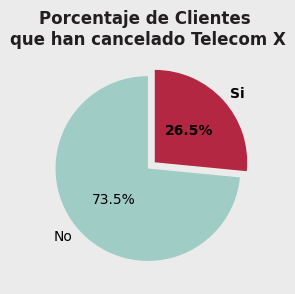

In [175]:
proporcion_cancelacion_viz().show();

Podemos verificar que si existe un desbalance de clases.

## <font color='#0066CC'>Balanceo de clases</font>
---

Al entrenar un modelo con la variable objetivo desbalanceada, puede ser que el patrón de los datos para la clase dominante sobresalga en relación a la clase con menor frecuencia, generando un modelo con un desempeño muy bajo para clasificar la clase de menor frecuencia.

Recordemos que el objetivo de nuestro modelo es **predecir a los clientes que pudieran cancelar su servicio**, que en nuestro caso, representan la clase con menor frecuencia. Por lo que el desbalance de clases si afectaría a nuestro modelo, para mitigar esta situación podemos usar 2 estrategias: **Oversampling** y **Undersampling**.

In [176]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

In [177]:
balanceo_opciones = {
    'sin_balancear': None,
    'oversample': SMOTE(random_state=26),
    'undersample': NearMiss(version=3)
}

### <font color='#003366'>Oversampling</font>
---

Consiste en **aumentar** la cantidad de datos de la clase que tiene menor frecuencia hasta que tenga la misma cantidad que la clase de mayor frecuencia. De esta manera, el modelo prestará más atención al patrón de los datos de la clase que tenía menor frecuencia al principio y podrá diferenciar mejor las dos clases.

Sin embargo, la desventaja de **sobreajustar el modelo** es posible, eso quiere decir que, el modelo puede 
especializarse demasiado en el patrón de los datos que son muy parecidos o idénticos, ya que son copiados o generados sintéticamente.

### <font color='#003366'>Undersampling</font>
---

Consiste en **reducir** la cantidad de datos de la clase que tiene mayor frecuencia hasta que tenga la misma 
cantidad que la clase de menor frecuencia.

La principal desventaja de la estrategia de undersampling es la **eliminación de datos que pueden ser muy importantes** para la comprensión del problema, especialmente cuando esta eliminación se realiza sin ningún criterio, como es el caso del undersampling aleatorio.

### <font color='#003366'>Otras Estrategias de Balanceo</font>
---

Cabe mencionar que existen otras estrategias que combinan las ventajas de los algoritmos de Oversampling y Undersampling.

## <font color='#0066CC'>Separación de Datos</font>
---

Antes de construir un modelo predictivo es importante separar el conjunto de datos en varios subconjuntos.

<center><img src='assets/separacion-datos-imagen.png'></center>


- El **conjunto de entrenamiento** se utiliza para entrenar los modelos. A partir de este conjunto, los modelos identifican patrones en los datos.
- El **conjunto de validación** se emplea para evaluar el desempeño de diferentes modelos con datos nuevos que no fueron utilizados en el entrenamiento.
- El **conjunto de prueba** se mantiene separado desde el inicio para simular datos del mundo real. No se utiliza en ninguna etapa del entrenamiento ni de la validación, sirviendo como una estimación de la capacidad del modelo elegido para generalizar y predecir nuevos datos.

In [178]:
from sklearn.model_selection import train_test_split

In [179]:
X, X_test, y, y_test = train_test_split(X_encoded, y_ini,
                                        test_size=0.3, # Define el tamaño del conjunto de prueba (test).
                                        stratify=y_ini, # Estratifica datos de modo que la cantidad de observaciones sea similar en ambos subconjuntos.
                                        random_state=7, # Permite obtener un resultado semi-aleatorio.
                                        )

Al hacer **una sóla división** para el conjunto de entrenamiento (train) y validación (val), aleatoriamente podríamos tener un patrón de división que sin darnos cuenta, afectaría los resultados de nuestro modelo. Más adelante veremos como la **validación cruzada** nos ayuda a solucionar esta situación.

In [180]:
X_train, X_val, y_train, y_val = train_test_split(X, y,
                                        stratify=y,
                                        random_state=7, 
                                        )

## <font color='#0066CC'>Creación de Modelos</font>
---

El Machine Learning (ML), como una subárea de la inteligencia artificial, se concentra en el desarrollo de algoritmos que son utilizados en la computadora para realizar tareas sin la necesidad de programar explícitamente las reglas que se utilizarán. 

Estos algoritmos basan sus decisiones a partir de datos con el objetivo de comprender e identificar el patrón existente en esos datos, para luego utilizar ese conocimiento en la realización de predicciones.

### <font color='#003366'>Elección de Modelos</font>
---

- **Dummy**:
    - Utiliza un algoritmo que asigna todas las clasificaciones a la clase que tiene mayor frecuencia. 
    - Este algoritmo sirve como un **criterio de comparación** para identificar si los otros modelos tienen un rendimiento mejor que la clasificación más simple posible.
- **Random Forest**:
    - Crea varios **árboles de decisión** y encuentra la mejor combinación para obtener el mejor resultado al realizar una previsión.
    - Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización. 
- **KNN (K Nearest Neighbors)**:
    - El algoritmo KNN se basa en el **cálculo de la distancia** entre los registros de la base de datos y busca elementos que estén cerca unos de otros (vecinos) para tomar la decisión de clasificación.
    - Debido a que utiliza cálculos de distancia, este algoritmo está influenciado por la escala de las variables, y por eso es necesario normalizar.

In [181]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [182]:
modelos = {
    'dummy': DummyClassifier(),
    'knn': KNeighborsClassifier(),
    'random_forest': RandomForestClassifier(max_depth=5, random_state=26)
}

### <font color='#003366'>Creación de Pipeline</font>
---

Para evaluar diferentes modelos con diferentes opciones de forma sistemática, vamos a usar una función **Pipeline()**, que nos ayuda a que ejecutar una serie de tareas en orden para llegar a un resultado.

En nuestro caso, nos yudara a realizar:
1. Normalización.
2. Balanceo.
3. Creación de modelo

In [183]:
from sklearn.pipeline import Pipeline # Pipeline sin balanceo
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline con balanceo

Vamos a crear una función que nos permita hacer una pipeline personalizada:

In [184]:
def crear_pipeline(modelo, normalizador, balanceador):
    pasos = []
    
    # Opciones de normalización.
    if normalizador is not None:
        pasos.append(('norm', normalizador))

    # Opciones de balanceo.
    if balanceador is not None:
        # Eligimos la clase de Pipeline correcta en base a  SI hay o NO hay balanceador
        pipeline_class = ImbPipeline
        pasos.append(('balanceo', balanceador))
    else:
        pipeline_class = Pipeline

    # Modelos.
    pasos.append(('modelo', modelo))
    
    return pipeline_class(pasos)

### <font color='#003366'>Relación entre Validación Cruzada e Intervalo de Confianza</font>
---

<center><img src='assets/validacion-cruzada-imagen.png'></center>

La validación del modelo de clasificación a partir de la separación de los datos en conjuntos de entrenamiento y validación hace que el resultado dependa en gran medida de esta división. Puede suceder que, de forma aleatoria, el patrón de los datos de validación sea diferente al de los datos de entrenamiento, lo que podría llevar a obtener un resultado mucho mejor o mucho peor que la realidad simplemente por suerte o mala suerte.

<u>En la validación cruzada, en lugar de separar los datos en entrenamiento y validación una sola vez, se dividen en varias partes de igual tamaño. En cada una de estas divisiones, se usa una parte para validación y todas las demás para entrenamiento.</u> Este proceso se repite hasta que todas las partes hayan sido utilizadas tanto para validación como para entrenamiento.

La validación cruzada nos permite tener un conjunto de resultados, más que un sólo resultado en concreto, por lo que podemos saber cual es el resultado promedio y cual será la desviación estándar, lo que nos lleva a poder generar un **intervalo de confianza**.

`Intervalo de confianza = Promedio de los resultados +- Desviación estándar de los resultados `

La razón de calcular un intervalo de confianza es para conocer la **estabilidad de nuestro modelo**.

Por ejemplo, de nada nos sirve un modelo con un buen resultado, si tiene una desviación estándar my grande, lo que nos puede decir que nuestro resultado pudo haber sido cuestión de suerte.

In [185]:
from sklearn.model_selection import cross_validate

Vamos a crear una función que nos permita hacer una validación cruzada y obtener diferentes resultados de una métrica:

In [186]:
def evaluar_pipeline(pipeline, X, y, cv, metrics):
    cv_resultados = cross_validate(
        estimator=pipeline,
        X=X, 
        y=y,
        cv=cv, # Permite estratificar los datos.
        scoring=metrics
    )
    return cv_resultados

## <font color='#0066CC'>Evaluación de Modelos</font>
---

**Exactitud o Accuracy**

Se utiliza para medir la proporción de datos previstos correctamente por el modelo en relación al total de los datos. Esta métrica es útil cuando las clases de la variable objetivo están balanceadas, es decir, cuando hay una cantidad equilibrada de datos para cada clase y una importancia equivalente de clasificación entre las categorías. 

**Recuperación o Recall**

Mide la proporción de datos positivos que fueron correctamente identificados por el modelo, es decir, revela la capacidad del modelo en evitar la clasificación incorrecta de datos positivos como negativos.

**Precisión o Precision**

Mide la proporción de datos clasificados como positivos que son realmente positivos, es decir, revela la capacidad del modelo en evitar la clasificación incorrecta de datos negativos como positivos.

**F1**

Proporciona un equilibrio entre el recall y la precisión.

In [187]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, f1_score

In [188]:
metricas_list_dicc = [] # Lista que almacenara diccionarios con los resultados de las métricas con validación cruzada.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=26) # Función que nos permite estratificar los datos.
# Métricas para evaluar modelos.
metricas = { 
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': make_scorer(precision_score, zero_division=0), # 'make_scorer' nos ayuda a evitar el problema de la división de 0/0.
    'f1': make_scorer(f1_score, zero_division=0)
}

In [189]:
for nombre_modelo, modelo in modelos.items():
    for nombre_norm, norm in norm_opciones.items():
        for nombre_bal, bal in balanceo_opciones.items():
            
            print(f"Probando: {nombre_modelo} | {nombre_norm} | {nombre_bal}")
            
            pipeline = crear_pipeline(modelo, norm, bal)
            
            try:
                cv_scores = evaluar_pipeline(pipeline, X, y, skf, metricas)
                
                # Guardar resultados
                fila = {
                    'modelo': nombre_modelo,
                    'normalizacion': nombre_norm,
                    'balanceo': nombre_bal
                }
                
                # Añadir media y std para cada métrica
                for metrica in metricas:
                    scores = cv_scores[f'test_{metrica}']
                    fila[f'{metrica}_media'] = scores.mean()
                    fila[f'{metrica}_std'] = scores.std()
                
                metricas_list_dicc.append(fila)
                
            except Exception as e:
                print(f"  Error: {e}")
                continue

Probando: dummy | sin_norm | sin_balancear
Probando: dummy | sin_norm | oversample
Probando: dummy | sin_norm | undersample
Probando: dummy | minmax | sin_balancear
Probando: dummy | minmax | oversample
Probando: dummy | minmax | undersample
Probando: knn | sin_norm | sin_balancear
Probando: knn | sin_norm | oversample
Probando: knn | sin_norm | undersample
Probando: knn | minmax | sin_balancear
Probando: knn | minmax | oversample
Probando: knn | minmax | undersample
Probando: random_forest | sin_norm | sin_balancear
Probando: random_forest | sin_norm | oversample
Probando: random_forest | sin_norm | undersample
Probando: random_forest | minmax | sin_balancear
Probando: random_forest | minmax | oversample
Probando: random_forest | minmax | undersample


La métrica elegida para evaluar nuestros modelos es **Recall o Recuperación**, porque representa el porcentaje de clientes que el modelo predice que van a cancelar, respecto a los clientes que realmente cancelan.

Por ejemplo, si en la realidad tenemos 100 clientes que cancelaron y el modelo predijo que 80 cancelarían su servicio, tendriamos un Recall de 0.8.

In [190]:
telecom_x_metricas = pd.DataFrame(metricas_list_dicc)
telecom_x_metricas.sort_values(by='recall_media', axis=0, ascending=False)

,modelo,normalizacion,balanceo,accuracy_media,accuracy_std,recall_media,recall_std,precision_media,precision_std,f1_media,f1_std
7,knn,sin_norm,oversample,0.683570,0.018040,0.762984,0.039886,0.443947,0.019348,0.561199,0.025295
16,random_forest,minmax,oversample,0.754158,0.008304,0.759934,0.028034,0.525256,0.010773,0.621086,0.016138
13,random_forest,sin_norm,oversample,0.766126,0.010154,0.723231,0.019406,0.544667,0.015053,0.621342,0.016359
10,knn,minmax,oversample,0.693712,0.008063,0.717861,0.025130,0.451372,0.009775,0.554188,0.014182
14,random_forest,sin_norm,undersample,0.777890,0.004397,0.681972,0.022880,0.567829,0.007158,0.619513,0.011162
17,random_forest,minmax,undersample,0.774239,0.014251,0.666646,0.029933,0.563646,0.024755,0.610437,0.021938
8,knn,sin_norm,undersample,0.730223,0.007397,0.625413,0.032586,0.493298,0.011307,0.551285,0.017633
11,knn,minmax,undersample,0.692089,0.013171,0.619245,0.043210,0.442688,0.017663,0.515856,0.023043
6,knn,sin_norm,sin_balancear,0.772008,0.014000,0.536682,0.029733,0.575495,0.028240,0.555279,0.027876
9,knn,minmax,sin_balancear,0.760243,0.011377,0.529031,0.032191,0.549898,0.021958,0.539065,0.025790


Considerando que el modelo knn debe normalizarse y que el modelo Random Forest no necesita la normalización. **El mejor modelo es Random Forest sin normalización con oversample**, ya que tiene un buen valor de Recall y su desviación estándar no es muy grande.

In [191]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [192]:
# Balanceo
oversample = SMOTE(random_state=26)
X_balanceada, y_balanceada = oversample.fit_resample(X,y)
# Creación de modelo
modelo_elegido = RandomForestClassifier(max_depth=5, random_state=26)
# Entrenamiento de modelo
modelo_elegido.fit(X_balanceada, y_balanceada)
# Predicción de modelo
y_previsto = modelo_elegido.predict(X_test)
# Reporte de métricas
print(classification_report(y_test, y_previsto))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1552
           1       0.51      0.73      0.60       561

    accuracy                           0.74      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.79      0.74      0.76      2113



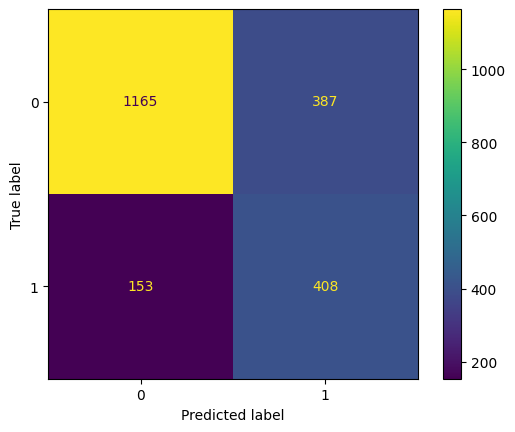

In [193]:
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto);

La **Matriz de Confusión** nos indica que nuestro modelo va a predecir muy bien a la mayoría de clientes que van a dejar Telecom X (408/561), pero a cambio, puede que en el proceso clasifiquemos como 'canceladores' a clientes que seguirán consumiendo el servicio (387).

# <strong><font color='#3399FF'>6. Interpretación y Conclusiones</font></strong> 
---

## <font color='#0066CC'>Análisis de la Importancia de las Variables</font>
---

Ahora que ya tenemos nuestro modelo, debemos preguntarnos **¿Son todas las variables explicativas relevantes para nuestro modelo?**

Es muy probable que existan varios atributos que no aportan valor, sino que complican nuestro modelado, añadiendo ruido a nuestro modelo. Ahora, la idea es seleccionar la mejor cantidad de variables para nuestro modelo. 

In [194]:
importancia_variables = modelo_elegido.feature_importances_ 
importancia_variables_df = pd.DataFrame(data={'Variables explicativas':modelo_elegido.feature_names_in_,
                                              'Importancia':100*importancia_variables.round(4)
                                              }).sort_values(by='Importancia', axis=0, ascending=False)

In [195]:
importancia_variables_df

,Variables explicativas,Importancia
26,contrato__Por_mes,21.64
7,seguridad_en_linea__No,13.31
16,soporte_tecnologico__No,8.74
28,metodo_pago__Cheque_electrónico,7.72
35,meses_antiguedad,6.40
25,contrato__Dos_años,6.30
10,copia_seguridad_en_linea__No,5.32
5,servicio_internet__Fibra_óptica,5.22
27,contrato__Un_año,3.19
8,seguridad_en_linea__Si,3.06


La variable explicativa más importante es `contrato__Por_mes`.

In [196]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Creamos una función que nos ayuda a calcular las métricas de cada subconjunto de variables.

In [197]:
def calcular_metricas(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metricas = {
        'accuracy_score': round(accuracy, 4),
        'precision_score': round(precision, 4),
        'recall_score': round(recall, 4),
        'f1_score': round(f1, 4)
    }

    return metricas

Ahora vamos a crear un DataFrame que nos permita comparar varias métricas dependiendo del número de variables explicativas que seleccionemos. Nuestro principal enfásis es **descubrir el número de varibles explicativas que puedan maximizar nuestro Recall**.

In [198]:
evaluacion_subconjuntos = pd.DataFrame(index=['accuracy_score', 'precision_score', 'recall_score', 'f1_score'])

oversample = SMOTE(random_state=26)
modelo_elegido = RandomForestClassifier(max_depth=5, random_state=26)
ct_features = [i if i != 0 else 1 for i in range(0,40,4)]

for i in ct_features:
    variables_elegidas = importancia_variables_df['Variables explicativas'].values[:i]
    X_balanceada_sel, y_balanceada = oversample.fit_resample(X[variables_elegidas], y)
    X_test_sel = X_test[variables_elegidas]
    modelo_elegido.fit(X_balanceada_sel, y_balanceada)
    y_previsto = modelo_elegido.predict(X_test_sel)
    metricas = calcular_metricas(y_test, y_previsto)
    evaluacion_subconjuntos[i] = list(metricas.values())

In [199]:
evaluacion_subconjuntos

,1,4,8,12,16,20,24,28,32,36
accuracy_score,0.6574,0.6957,0.7459,0.7525,0.7430,0.7487,0.7473,0.7492,0.7520,0.7549
precision_score,0.4299,0.4589,0.5149,0.5240,0.5112,0.5187,0.5167,0.5193,0.5234,0.5282
recall_score,0.8913,0.8164,0.7398,0.7398,0.7308,0.7415,0.7433,0.7433,0.7380,0.7184
f1_score,0.5800,0.5876,0.6072,0.6135,0.6016,0.6104,0.6096,0.6114,0.6124,0.6088


De esta manera, observamos como afecta el número de vairables explicativas que usamos en el desempeño del modelo. Podriamos decir que **con las primeras 12 variables tenemos un modelo equilibrado**.

## <font color='#0066CC'>Conclusión</font>
---

### <font color='#003366'>Resumen del Modelo Elegido</font>
---

El objetivo del proyecto es anticiparse al problema de la cancelación,  con principal enfoque en prever qué clientes tienen mayor probabilidad de cancelar su servicio, por lo que la mejor métrica para evaluar nuestro modelo es Recall.

El modelo que mejor se ajusto a nuestro objetivo fue **Random Forest con Oversampling y con 12 variables**.

In [200]:
evaluacion_subconjuntos[12]*100

accuracy_score     75.25
precision_score    52.40
recall_score       73.98
f1_score           61.35
Name: 12, dtype: float64

**Recall**: 73.98% (detectamos 3 de cada 4 cancelaciones reales).

### <font color='#003366'>Variables con Mayor Influencia en el Modelo</font>
---

Top 12 de variables:

In [206]:
importancia_variables_df.iloc[:12]

,Variables explicativas,Importancia
26,contrato__Por_mes,21.64
7,seguridad_en_linea__No,13.31
16,soporte_tecnologico__No,8.74
28,metodo_pago__Cheque_electrónico,7.72
35,meses_antiguedad,6.40
25,contrato__Dos_años,6.30
10,copia_seguridad_en_linea__No,5.32
5,servicio_internet__Fibra_óptica,5.22
27,contrato__Un_año,3.19
8,seguridad_en_linea__Si,3.06


`contrato__Por_mes` es la variable explicativa con más peso en el modelo en relación con las otras opciones de contratación (1 año y 2 años) lo que podría indicar: 
- que los clientes no se sienten comprometidos con un servicio a largo plazo con Telecom X,
- o que hay un nicho de clientes que prefieren un servicio más esporádico.

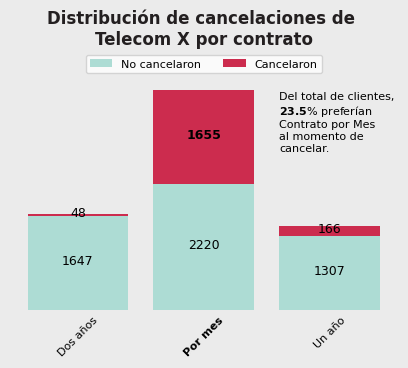

In [202]:
contrato_viz().show()

`seguridad_en_linea__No` y `soporte_tecnologico__No` tienen un peso que sobrepasa a sus contrapartes (`seguridad_en_linea__Si` y `soporte_tecnologico__Si`), posiblemente indicando que los clientes que conservan su contratación prefieren contratar servicios extras.

`meses_antiguedad` tiene una tendencia más clara en la distinción de los clientes que cancelan contra los que conservan su servicio, siendo el umbral clave los primeros 6 meses de contratación.

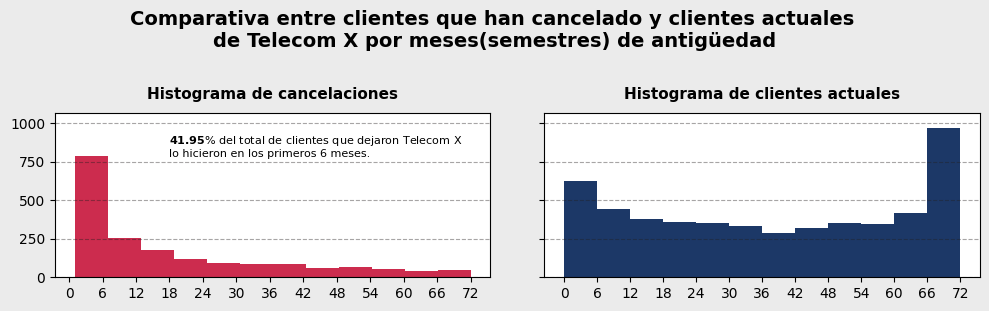

In [203]:
meses_antiguedad_viz().show()

`metodo_pago__Cheque_electrónico` tiene una influencia relativamente mucho más grande que otros métodos de pago (por correo, con crédito y por transferencia), un posible motivo podría ser alguna dificultad al momento de procesar pagos por Cheque eléctronico, como tiempos de confirmación muy largos, cheques rechazados, etc.

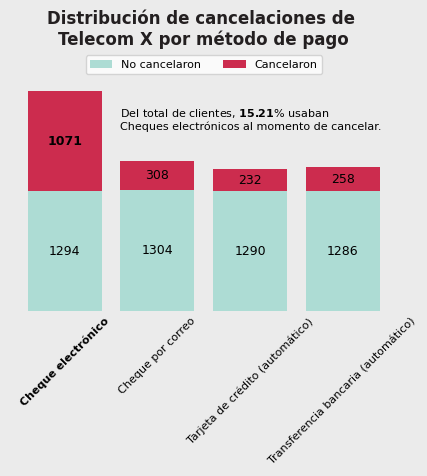

In [ ]:
metodo_pago_viz().show();

### <font color='#003366'>Estrategias de Retención</font>
---

|Variable|Estrategia(s)|
|-|-|
|`contrato__Por_mes`|Incentivar contratos anuales mediante promociones que ofrezcan servicios extras o descuentos generales.|
|`seguridad_en_linea__No` y otros servicios que extras que dependen de internet|Realizar campañas publicitarias que den a conocer los beneficios de contratar servicios extras.|
|`metodo_pago__Cheque_electrónico`|Investigar si el proceso de pago es óptimo, tanto el software empleado como la lógica de los pasos. Si es necesario, actualizar.|
|`meses_antiguedad`|Ofrecer paquete promocional para clientes nuevos por 1 año con descuento y que además, ofrezca el servicio extra más popular entre los clientes que conservan su servicio de forma gratuita.|

De forma general, diseñar un **proceso de encuentas de  satisfacción** que nos ayude a conocer:
- De los clientes fieles, ¿por qué prefieren Telecom X sobre otras empresas de telecomunicaciones?
- De los clientes que cancelan, ¿por qué motivo cancelaron su servicio?

### <font color='#003366'>Limitaciones del Modelo</font>
---

- La precisión del 52.4% implica que 1 de cada 2 alertas es falsa, es decir, que podríamos molestar a clientes que no van a cancelar.

- No se incluyeron variables externas, como variables económicas que nos den el panorama general de las zonas geográficas que abarca Telecom X; o variables de competencia, que permiten evaluar que tan buenos son los servicios de Telecom X en relación a la competencia.

- El modelo es estático, lo que quiere decir que, necesita reentrenarse periódicamente.